<center> <span style = "color:#4D5C2C"> <h1> 2 - tier RAG Chatbot </h1> </span> </center> 

<center> <span style = "color:navy"> <h2> Text Pre-Processing and Chunking Module </h2> </span> </center> 
This module implements a deterministic pipeline for converting raw markdown documents into semantically coherent, token-bounded text chunks suitable for downstream retrieval or RAG-based systems. 
<h3 style = "color:brown"> 🔤 Tokenisation </h3>
A lightweight whitespace tokenizer <strong><em>(tokenize)</em></strong> decomposes input text into a token list. This avoids model-specific tokenisation overhead while enabling deterministic token counting for chunk boundaries. 
<h3 style = "color:brown">  ➗ Token-Bounded Splitting  </h3>
The <strong><em>split_by_tokens</em></strong> function segments long textual sequences into overlapping windows. max_tokens = 450 defines the upper token limit for each chunk. overlap = 50 preserves contextual continuity between adjacent chunks, mitigating information loss at boundaries. This sliding-window approach ensures each segment remains model-friendly while maintaining semantic linkage. 
<h3 span style = "color:brown">  🧩 Markdown Structural Parsing  </h3> 
<strong><em>extract_sections</em></strong> uses a regular expression to identify markdown headers (<strong><em>#</em></strong> through <strong><em>######</em></strong>). Each header demarcates a semantic section, and all text until the next header is treated as that section’s content. This preserves author-defined structure, ensuring hierarchical segmentation rather than arbitrary slicing. 
<h3 style = "color:brown"> 🧽 Text Normalisation </h3>
<strong><em>clean_text</em></strong> removes markdown artefacts (e.g., headers, emphasis markers, escaped characters). It collapses whitespace and produces a clean, plain-text representation optimised for lexical processing and embedding. 
<h3 style = "color:brown"> 🗃️ Chunk Assembly  </h3>
<strong><em>extract_chunks_from_markdown</em></strong> orchestrates the pipeline: 
<ol>
    <li> Reads the raw <em><strong>.md</em></strong> file. </li>
    <li>Extracts sections using markdown headers.  </li>
    <li>Cleans each section’s content. </li>
    <li>Splits oversized content using the token windowing mechanism. </li>
    <li>Generates structured chunk objects of the form: <br>
    { <br>
      <span style = "color:red"> "id": </span> <span style = "color:green"> "&lt;file_prefix&gt;_&lt;index&gt;", </span> <br> 
      <span style = "color:red"> "section": </span> <span style = "color:green"> "&lt;markdown_section_title&gt;", </span> <br>
      <span style = "color:red"> "text": </span> <span style = "color:green"> "&lt;cleaned_and_token_limited_chunk&gt;", </span> <br> 
      <span style = "color:red"> "source_file": </span> <span style = "color:green"> "&lt;filename&gt;.md" </span> <br>
    } <br> </li>
    <li>Output The module returns a list of uniformly structured chunk objects ready for indexing, embedding, or corpus construction in retrieval-augmented systems.</li>
</ol>

In [1]:
import re
import json
import os
from pathlib import Path
from typing import List


In [66]:


def tokenize(text):
    """Simple whitespace tokenizer."""
    return text.split()

def split_by_tokens(text, max_tokens=450, overlap=50):
    """Split a long block of text into token-limited chunks."""
    tokens = tokenize(text)
    chunks = []
    start = 0

    while start < len(tokens):
        end = start + max_tokens
        chunk = " ".join(tokens[start:end])
        chunks.append(chunk)
        start = end - overlap  # overlap to preserve context

        if start < 0:
            start = 0

    return chunks

def extract_sections(md_text):
    """
    Extract semantic sections based on markdown headers #, ##, ###.
    Returns list of {section_title, content}.
    """
    pattern = r"(#{1,6}\s.*)"
    headers = list(re.finditer(pattern, md_text))

    sections = []
    for i, header in enumerate(headers):
        section_title = header.group(1).strip()
        start = header.end()
        end = headers[i + 1].start() if i + 1 < len(headers) else len(md_text)
        content = md_text[start:end].strip()
        sections.append({"title": section_title, "content": content})

    return sections

def clean_text(text):
    """Remove markdown formatting."""
    text = re.sub(r"#.*", "", text)
    text = re.sub(r"[*_`>]", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.rstrip("\\").strip()
    text = text.replace("\\&", "&")
    return text.strip()

def extract_chunks_from_markdown(md_path, file_id_prefix):
    """Return a list of chunk objects from one markdown file."""
    raw = Path(md_path).read_text(encoding="utf-8")

    sections = extract_sections(raw)
    all_chunks = []
    chunk_index = 1
    
    for sec in sections:
        clean_content = clean_text(sec["content"])

        # If a section exceeds ~450 tokens, split it
        token_chunks = split_by_tokens(clean_content)

        for chunk_text in token_chunks:
            chunk_obj = {
                "id": f"{file_id_prefix}_{chunk_index}",
                "section": sec["title"].lstrip("# ").strip(),
                "text": chunk_text,
                "source_file": Path(md_path).name
            }
            all_chunks.append(chunk_obj)
            chunk_index += 1

    return all_chunks

# ---------- Example for a single file ----------

md_file = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\tier1_knowledge\courses\Postgraduate research\PhD Theology.md"
chunks = extract_chunks_from_markdown(md_file, file_id_prefix="phd_system_science")

print("Generated chunks:", len(chunks))
print(json.dumps(chunks, indent=2))  # preview first 2 chunks


Generated chunks: 7
[
  {
    "id": "phd_theology_1",
    "section": "Course Overview",
    "text": "Course Name: PhD Theology. Research programme: Theology research degrees Course Duration: Full time: 3 years of research, with up to 12 months of writing up if required. Part time: 6 years of research, with up to 24 months of writing up if required.",
    "source_file": "PhD Theology.md"
  },
  {
    "id": "phd_theology_2",
    "section": "Entry Requirements (UK)",
    "text": "You should normally have, or expect to obtain, at least a 2:1 Honours degree, or international equivalent, in a discipline relevant to your intended area of research. It is not essential to contact a prospective supervisor before submitting your application, but doing so may be helpful in refining your research ideas and ensuring alignment with available expertise.",
    "source_file": "PhD Theology.md"
  },
  {
    "id": "phd_theology_3",
    "section": "Entry Requirements (International)",
    "text": "English 

<center>
  <span style="color:navy;">
    <h2> JSON Persistence for Chunk Storage </h2>
  </span>
</center>

This component ensures that newly generated text chunks are appended to an existing JSON corpus while maintaining idempotent, file-safe behaviour.

<h3 style="color:brown;"> 🗄️ File Initialisation </h3>
The script checks whether the target JSON file exists.<br>
If present, it loads the existing records.<br>
If absent, it initializes an empty list to store new chunk data.

<h3 style="color:brown;"> 🔗 Data Aggregation </h3>
Newly produced <strong><em>chunks</em></strong> are appended to the in-memory dataset using  
<strong><em>extend()</em></strong>, preserving prior entries while adding the latest batch.

<h3 style="color:brown;"> 💾 Persistent Storage </h3>
The updated dataset is saved back to disk using <strong><em>json.dump()</em></strong> with:

<ul>
  <li><strong>indent=2</strong> for readable, structured formatting</li>
  <li><strong>ensure_ascii=False</strong> to retain full Unicode characters</li>
</ul>

<h3 style="color:brown;"> 📣 Execution Feedback </h3>
A confirmation message outputs the destination file path after successful write.


In [2]:
import json

path = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\tier1_knowledge\\"
path_2 = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\tier2_knowledge\\"
OUTPUT_JSON = path + r"single_course_chunks.json"


In [67]:


# Load existing data if file exists
if os.path.exists(OUTPUT_JSON):
    with open(OUTPUT_JSON, "r", encoding="utf-8") as f:
        existing_data = json.load(f)
else:
    existing_data = []

# Add new chunks
existing_data.extend(chunks)
                                                                                                                                                                
# Save back to JSON
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(existing_data, f, indent=2, ensure_ascii=False)
print("Saved chunks to:", OUTPUT_JSON)


NameError: name 'chunks' is not defined

<center><h2 style="color:navy;"> Embedding Generation for Knowledge Base Chunks </h2></center>
This module transforms cleaned and chunked textual data into high-dimensional semantic embeddings optimised for retrieval in the RAG pipeline.

<h3 style="color:brown;"> 🧠 Model Initialisation </h3> The embedding model <strong><em>BAAI/bge-large-en-v1.5</em></strong> (1024-dimensional, instruction-tuned) is loaded to ensure stable, retrieval-optimised representations suitable for dense vector search. <h3 style="color:brown;"> 📥 Dataset Loading </h3> The JSON knowledge-base file is opened and parsed, extracting all text chunks into memory. Each chunk represents a semantically coherent unit derived from earlier preprocessing. <h3 style="color:brown;"> 📝 Instruction Prefixing </h3> Every chunk is prepended with the BGE instruction <strong><em>“Represent this document:”</em></strong> to match the model’s contrastive training format and improve embedding alignment. <h3 style="color:brown;"> ⚙️ Batch Embedding Generation </h3> All prefixed chunks are encoded in efficient mini-batches using the SentenceTransformers pipeline with: <ul> <li><strong>convert_to_numpy=True</strong> for NumPy-friendly storage</li> <li><strong>normalize_embeddings=True</strong> to produce L2-normalised vectors</li> </ul> These settings optimise the embeddings for cosine-similarity retrieval. <h3 style="color:brown;"> 💾 Embedding Persistence </h3> The final embedding matrix is saved as a <strong>.npy</strong> file using NumPy, ensuring: <ul> <li>fast reuse during FAISS index construction</li> <li>elimination of repeated model inference during experiments</li> </ul>



In [25]:
from sentence_transformers import SentenceTransformer

# Load correct embedding model (1024-dim)
embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

C:\Users\Harashaa Harshini\rag_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████| 391/391 [00:01<00:00, 218.89it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
from sentence_transformers import SentenceTransformer

# Load correct embedding model (1024-dim)
embed_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

# Load JSON dataset
with open(OUTPUT_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

texts = [item["text"] for item in data]

instruction = "Represent this document: "
prefixed_texts = [instruction + t for t in texts]

embeddings = embed_model.encode(
    prefixed_texts,
    batch_size=32,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", embeddings)


import numpy as np
np.save(embeddings_npy, embeddings)


Loading weights: 100%|█████████████████████| 391/391 [00:03<00:00, 117.55it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: [[ 1.4148261e-02 -2.4981959e-02  1.7673951e-02 ... -3.1226087e-02
   1.7324035e-03  1.8250085e-04]
 [ 2.3371403e-03 -4.9946692e-02  3.3589757e-05 ... -2.3842389e-02
   9.5087970e-03 -3.0406354e-02]
 [-1.3320144e-04 -2.2518482e-02 -2.8543141e-02 ... -2.0292979e-02
   7.7037537e-04  1.1209542e-02]
 ...
 [-2.9855967e-03 -2.4443896e-02  1.5375638e-02 ... -4.6739813e-02
  -2.5983883e-02  5.2858181e-02]
 [-2.5817640e-02  2.1302065e-02 -8.3631566e-03 ... -2.9684775e-02
  -2.3139836e-02  3.2501329e-02]
 [-1.2465073e-02 -3.0425863e-02  4.6244297e-02 ...  3.7521957e-03
  -1.6420787e-02  2.6674515e-02]]


In [3]:
# Save embeddings to a .npy file
embeddings_npy = path + "embeddings.npy" 


<center><h2 style="color:navy;">3D UMAP Projection of Embedding Space</h2></center>
This component performs dimensionality reduction and visual exploration of the embedding space, enabling qualitative assessment of semantic structure within the knowledge base.

<h3 style="color:brown;"> 📥 Embedding Loading </h3> The previously generated 1024-dimensional embedding matrix is loaded from disk into memory to serve as the input for dimensionality reduction and visual inspection. <h3 style="color:brown;"> 🔻 Dimensionality Reduction via UMAP </h3> The module applies <strong><em>UMAP (Uniform Manifold Approximation and Projection)</em></strong> in a **3-component configuration** using cosine distance. This transforms the high-dimensional vectors into a compact latent space while preserving local and global structure. <h3 style="color:brown;"> 🎨 Semantic Colour Encoding </h3> A single UMAP component is used to colour-code each point, revealing semantic gradients and cluster tendencies across the reduced manifold. <h3 style="color:brown;"> 📊 Scientific 3D Visualisation </h3> A 3D scatter plot is produced with: <ul> <li>soft grey background panes for clarity,</li> <li>a light scientific grid,</li> <li>axis labels for interpretability,</li> <li>a <strong><em>coolwarm</em></strong> colormap to highlight variation.</li> </ul> This provides an interpretable spatial representation of relationships between text chunks. <h3 style="color:brown;"> 💾 Figure Export </h3> The final UMAP projection is exported to the designated images directory, ensuring reproducibility and availability for dissertation figures.

In [278]:
# Path to the directory containing all image assets used for visualisation
iamge_path = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\images"

Loaded embeddings: (228, 1024)


C:\Users\Harashaa Harshini\rag_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 3D shape: (228, 3)


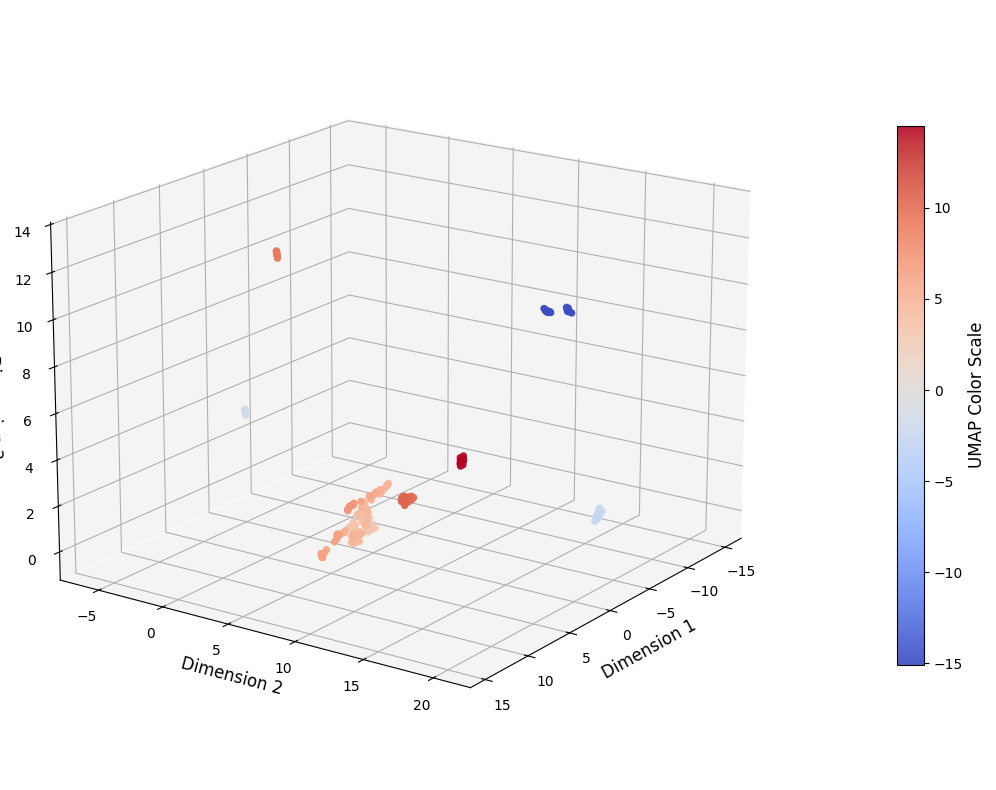

In [40]:
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 


# Load embeddings

embeddings = np.load(embeddings_npy)
print("Loaded embeddings:", embeddings.shape)


# Run UMAP in 3D

umap_3d = umap.UMAP(
    n_components=3,
    metric="cosine",
    random_state=42
)

emb_3d = umap_3d.fit_transform(embeddings)
print("UMAP 3D shape:", emb_3d.shape)


# Prepare color values
# Use UMAP dimension 1 as the color scaling variable
color_values = emb_3d[:, 0]


# Create figure + scientific-style axes 

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Light grey background planes
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_facecolor((0.92, 0.92, 0.92, 1.0))  # soft grey
    axis.pane.set_edgecolor("white")

# Light grid (optional)
ax.grid(True, linewidth=0.5, color=(0.85, 0.85, 0.85, 1))


# Scatter plot with scientific colormap

scatter = ax.scatter(
    emb_3d[:, 0],
    emb_3d[:, 1],
    emb_3d[:, 2],
    c=color_values,
    cmap="coolwarm",  # blue → white → red like your example
    s=18,
    alpha=0.9
)


# Axis labels

ax.set_xlabel("Dimension 1", fontsize=12)
ax.set_ylabel("Dimension 2", fontsize=12)
ax.set_zlabel("Dimension 3", fontsize=12)


# Add colorbar

cbar = fig.colorbar(scatter, shrink=0.7, pad=0.1)
cbar.set_label("UMAP Color Scale", fontsize=12)


# Improve camera angle (similar to your image)

ax.view_init(elev=18, azim=35)

plt.tight_layout()
plt.savefig(iamge_path + "3D UMAP Projection of Course Embeddings")
plt.show()

<center> <span style="color:navy;"> <h2> FAISS Index Construction for Dense Vector Retrieval </h2> </span> </center>

This module builds a high-performance vector index using FAISS to enable efficient similarity-based retrieval within the RAG pipeline.

<h3 style="color:brown;"> 📥 Embedding Loading </h3> The precomputed semantic embeddings are loaded from disk and cast to <strong><em>float32</em></strong>, the datatype required by FAISS for inner-product search. The embedding dimensionality (1024 for BGE-large) is extracted directly from the matrix shape for index initialisation. <h3 style="color:brown;"> 🧮 Index Initialisation </h3> A **FAISS IndexFlatIP** structure is created to support dense retrieval using **inner product similarity**, which is appropriate because all embeddings were L2-normalised during generation. <h3 style="color:brown;"> ➕ Vector Insertion </h3> All embedding vectors are inserted into the FAISS index in a single operation, making them immediately searchable without additional training or quantisation. <h3 style="color:brown;"> 💾 Index Persistence </h3> The fully populated FAISS index is written to disk as <strong><em>vector_index.faiss</em></strong>, allowing the retrieval module to load it instantly during inference without recomputation. <h3 style="color:brown;"> 📣 Completion Feedback </h3> A confirmation message prints the number of stored vectors, verifying that all chunks have been successfully indexed.

In [11]:
import faiss
import numpy as np

# Load the saved embeddings
embeddings = np.load(embeddings_npy).astype("float32")
dimension = embeddings.shape[1]  # 1024 for BGE-large


# Create FAISS index using Inner Product
index = faiss.IndexFlatIP(dimension)


# Add embeddings
index.add(embeddings)


# Save index 
faiss.write_index(index, path + r"vector_index.faiss")

print("Total vectors in index:", index.ntotal)

Total vectors in index: 228


In [5]:
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from groq import Groq
import torch


<center> <span style="color:navy;"> <h2> Retrieval-Augmented Answer Generation Function </h2> </span> </center>

This component implements the core Retrieval-Augmented Generation (RAG) workflow by embedding user queries, retrieving relevant knowledge-base chunks, constructing a context-aware prompt, and generating grounded responses through a lightweight LLM hosted on Groq.

<h3 style="color:brown;"> 📥 Query Embedding </h3> The user’s input query is embedded using the same <strong><em>BGE-large</em></strong> model employed for chunk embeddings. The instruction prefix <strong><em>“Represent this document:”</em></strong> is applied to maintain representational consistency. The resulting 1024-dimensional vector is normalised and reshaped for FAISS retrieval. <h3 style="color:brown;"> 🔍 Top-K Semantic Retrieval </h3> The embedded query is passed to the FAISS index, which returns the <strong><em>k most similar chunks</em></strong> using inner-product similarity. These retrieved segments form the grounding evidence for the answer. <h3 style="color:brown;"> 🧩 Context Assembly </h3> All retrieved text chunks are concatenated into a unified context block using clear separators. This ensures the downstream LLM receives structured, interpretable evidence extracted directly from the knowledge base. <h3 style="color:brown;"> 🧠 LLM-Driven Answer Generation </h3> A retrieval-aware prompt is constructed and submitted to the <strong><em>LLaMA-3.1-8B-Instant</em></strong> model on Groq. The model is instructed to: <ul> <li>answer exclusively using the retrieved context,</li> <li>avoid external knowledge,</li> <li>emit a fallback message when information is missing.</li> </ul> <h3 style="color:brown;"> 📤 Output Delivery </h3> The function returns: <ul> <li>the final grounded answer generated by the LLM, and</li> <li>the list of retrieved supporting chunks.</li> </ul> This forms the complete Tier-1 RAG pipeline used for deterministic, context-bound university support responses.

In [27]:
with open(OUTPUT_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

texts = [item["text"] for item in data]

client = Groq(api_key="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")

from groq import Groq

def rag_answer(query, k=5):
    # Step 1 — embed query
    query_embedding = embed_model.encode(
        instruction + query,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32").reshape(1, -1)

    # Step 2 — retrieve
    scores, indices = index.search(query_embedding, k)
    retrieved_chunks = [texts[i] for i in indices[0]]

    # Step 3 — context
    context = "\n\n---\n\n".join(retrieved_chunks)

    prompt = f"""
You are a university support assistant.
Answer ONLY using information in <context>.
If answer is not found, say:
"I don’t have that information in the university knowledge base."

<context>
{context}
</context>

QUESTION: {query}

ANSWER:
"""

    # Step 4 — Groq call (FIXED MODEL)
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=256
    )

    answer = response.choices[0].message.content.strip() 

    return answer, retrieved_chunks


<center> <span style="color:navy;"> <h2> Two-Tier Routing and Access Control Logic </h2> </span> </center> <h3 style="color:brown;"> 🧠 Intent Classification </h3> The <strong><em>classify_intent()</em></strong> function distinguishes between general (Tier-1) and personal (Tier-2) queries using lightweight keyword-based detection. <h3 style="color:brown;"> 🔐 Authentication Enforcement </h3> The <strong><em>check_access()</em></strong> function ensures that personal queries are processed only when the user is authenticated, preventing unauthorised access. <h3 style="color:brown;"> 🔄 Tier Routing Wrapper </h3> The <strong><em>route_and_answer()</em></strong> function acts as the decision boundary, routing validated queries to either the public RAG engine (Tier-1) or the personalised retrieval engine (Tier-2). <h3 style="color:brown;"> 🎯 Authorised Data Scope Definition </h3> The <strong><em>get_authorised_user_scope()</em></strong> function restricts accessible records based on role, limiting students to their own data and lecturers to their advisee students, thereby enforcing hierarchical access control.

In [28]:
# Intent classifier: determines whether a query is general or personal
def classify_intent(query: str) -> str:
    """
    Classifies user query into 'general' (Tier-1) or 'personal' (Tier-2)
    based on keyword detection.
    """
    personal_keywords = [
        "my ",
        "am i",
        "which students",
        "my students",
        "students i advise",
        "students am i advising", 
        "do I ",
        "my grades",
        "my module",
        "my timetable",
        "my course"
    ]

    
    query_lower = query.lower()

    if any(keyword in query_lower for keyword in personal_keywords):
        return "personal"
    
    return "general"


# Access control: enforces authentication for personal queries
def check_access(intent: str, user: dict) -> bool:
    """
    Validates whether the user is authorised to access
    personal (Tier-2) information.
    """
    if intent == "general":
        return True
    
    if intent == "personal":
        return user.get("authenticated", False)
    
    return False


# Routing wrapper: directs queries to the appropriate tier
def route_and_answer(query: str, user: dict):
    """
    Routes the query to Tier-1 (public RAG) or
    Tier-2 (personal engine) after access validation.
    """
    intent = classify_intent(query)
    print(f"[LOG] Intent detected: {intent}")
    
    if not check_access(intent, user):
        return ("Access denied. Please log in using: "
        "login('<user_id>', '<password>')"), None
    
    if intent == "general":
        print("[LOG] Routing to Tier-1 RAG")
        return rag_answer(query)
    
    if intent == "personal":
        print("[LOG] Routing to Tier-2 Personal Engine")
        return tier2_personal_engine(query, user)


# Authorised scope: defines accessible user IDs based on role

def get_authorised_user_scope(current_user):
    """
    Returns the list of user_ids that the current user
    is permitted to access based on role.
    """
    if current_user["entity_type"] == "student":
        return [current_user["user_id"]]

    if current_user["entity_type"] == "staff":

        if current_user["role"] == "Lecturer":
            return current_user["advisee_students"] + [current_user["staff_id"]]

        if current_user["role"] == "Admin":
            return [current_user["staff_id"]]

<center> <span style="color:navy;"> <h2> Query Evaluation and Retrieval Inspection </h2> </span> </center>

This cell performs an end-to-end evaluation of the RAG pipeline by issuing a sample query, generating a grounded response, and displaying the supporting retrieved evidence.

<h3 style="color:brown;"> 📝 Query Invocation </h3> A representative user query is passed to the <strong><em>rag_answer()</em></strong> function to simulate real-world information requests within the university support context. <h3 style="color:brown;"> 🤖 Model-Generated Answer </h3> The grounded answer returned by the LLM is printed, allowing verification that: <ul> <li>the response correctly reflects retrieved context,</li> <li>the model respects the “context-only” instruction, and</li> <li>hallucinations are suppressed through strict prompting.</li> </ul> <h3 style="color:brown;"> 📄 Retrieved Evidence Chunks </h3> Each of the top-K retrieved text segments used by the LLM to construct its answer is displayed. This enables transparent inspection of: <ul> <li>retrieval quality,</li> <li>semantic relevance,</li> <li>chunk-level grounding,</li> <li>whether the index returns the correct domain information.</li> </ul> <h3 style="color:brown;"> 🔍 RAG Debugging Utility </h3> This evaluation cell is essential for debugging retrieval behaviour, validating embedding quality, and demonstrating the explainability of the RAG workflow.


In [16]:
query = "How many modules are there in the MSc Data Science and AI course?"
answer, retrieved = rag_answer(query, none)

print("ANSWER:\n", answer)
print("\nRETRIEVED CHUNKS:")
for c in retrieved:
    print("\n---\n", c)


ANSWER:
 There are 3 main sections of modules in the MSc Data Science and AI course: 

1. Core modules (listed in the first section)
2. Compulsory modules (listed in the second section)
3. Optional modules (listed in the third section)

However, to answer the question directly, I don't have a total number of modules in the university knowledge base.

RETRIEVED CHUNKS:

---
 Course Name: MSc Artificial Intelligence and Data Science. Duration: 1 year. Mode of Study: Full-time .

---
 The MSc in Data Science and Artificial Intelligence is a fast-track programme designed for individuals who want to change direction, switch careers, or upskill into a high-demand technical field. Teaching takes place in the £4.5 million Centre of Excellence for Data Science, Artificial Intelligence and Modelling (DAIM), which provides an advanced environment dedicated to applied data, analytics, and AI education. The programme is open to students from both STEM and non-STEM backgrounds. It is structured as a

In [16]:
query = "How many modules are there in the MSc Data Science and AI course?"
answer, retrieved = route_and_answer(query, None)

print("ANSWER:\n", answer)

[LOG] Intent detected: general
[LOG] Routing to Tier-1 RAG
ANSWER:
 There are 7 modules in the MSc in Data Science and Artificial Intelligence course:

1. Introduction to Programming (core, 20 credits)
2. Fundamentals of Data Science (core, 20 credits)
3. Understanding Artificial Intelligence (core, 20 credits)
4. Big Data and Data Mining (core, 20 credits)
5. Applied Artificial Intelligence (core, 20 credits)
6. Research and Application in Artificial Intelligence and Data Science (core, 20 credits)
7. Artificial Intelligence and Data Science Research Project (core, 60 credits)


<center> <span style="color:navy;"> <h2> Programme–Module Mapping Extraction </h2> </span> </center>

This cell constructs a structured mapping between academic programmes and their associated modules directly from the Tier-1 chunked dataset. The mapping ensures institutional consistency between public course data and the synthetic student records generated for Tier-2.
 <ul> 
<li><strong style="color:brown;"> 📂 Programme Identification </strong> Each chunk is parsed to extract the programme name using the <strong><em>source_file</em></strong> field, which serves as the authoritative identifier for the course. This guarantees that all module data remains anchored to its correct academic programme.</li> <li><strong style="color:brown;"> 📚 Module Section Detection </strong> Relevant module information is detected by filtering chunks whose <strong><em>section</em></strong> field contains keywords such as <em>Modules</em>, <em>What you'll study</em>, or <em>Course structure</em>. This prevents contamination from non-academic sections such as entry requirements or fee descriptions.</li><li> <strong style="color:brown;"> ✂️ Heuristic Module Extraction </strong> Module titles are extracted using lightweight text segmentation heuristics, splitting structured content into candidate module strings. This approach balances structural parsing with robustness against formatting variability.</li><li> <strong style="color:brown;"> 🔁 De-duplication and Structuring </strong> Extracted module titles are temporarily stored in a <strong>set</strong> to eliminate duplicates before being converted into a dictionary structure of the form: <ul> <li><code>programme_modules = { "Programme Name": [module_1, module_2, ...] }</code></li> </ul> <li><strong style="color:brown;"> 🔗 Cross-Tier Alignment </strong> The resulting programme–module mapping serves as the authoritative academic schema for Tier-2 synthetic data generation, ensuring that all student records reference real modules present in the Tier-1 knowledge base.</li> </ul></ul>

In [19]:
import json
from collections import defaultdict
import re

with open(path + "single_course_chunks.json", "r", encoding="utf-8") as f:
    tier1_chunks = json.load(f)

programme_modules = defaultdict(set)

for chunk in tier1_chunks:
    
    # Extract programme name from source_file
    source_file = chunk.get("source_file", "")
    programme = source_file.replace(".md", "").strip()
    
    section = chunk.get("section", "").lower()
    text = chunk.get("text", "").strip()
    
    # Detect module-related sections
    if any(keyword in section for keyword in ["module", "what you'll study", "course structure"]):
        
        # Basic extraction — split long text into candidate lines
        possible_modules = re.split(r'\n|\.|-', text)
        
        for item in possible_modules:
            item = item.strip()
            
            # Keep reasonably short lines (likely module titles)
            if 3 < len(item) < 120:
                programme_modules[programme].add(item)

# Convert sets to lists
programme_modules = {
    k: list(v) for k, v in programme_modules.items()
}

print(f"Extracted modules for {len(programme_modules)} programmes")


Extracted modules for 20 programmes


<center> <span style="color:navy;"> <h2> Programme Level Inference Logic </h2> </span> </center>

This cell defines a rule-based function to infer the academic level (UG / PG / PhD) directly from the programme title. The objective is to preserve institutional consistency when generating synthetic student records for Tier-2.

<h3 style="color:brown;"> 🎓 Level Derivation from Programme Metadata </h3> The function analyses the programme name string and assigns the appropriate academic level based on common institutional naming conventions (e.g., <em>MSc</em>, <em>BA</em>, <em>PhD</em>). This ensures that student role classification is derived from authoritative course metadata rather than randomly assigned. <h3 style="color:brown;"> 🧠 Rule-Based Classification Strategy </h3> The inference follows a deterministic keyword-matching approach: <ul> <li><strong>PhD</strong> → If the programme name contains “phd”.</li> <li><strong>PG</strong> → If the programme name contains “msc” or “ma”.</li> <li><strong>UG</strong> → If the programme name contains “ba” or “bsc”.</li> <li><strong>Fallback</strong> → Defaults to UG if no match is detected.</li> </ul> <h3 style="color:brown;"> 🔒 Institutional Consistency </h3> By deriving student level directly from programme metadata, this function prevents structural inconsistencies (e.g., assigning a PhD role to an undergraduate programme), thereby maintaining semantic and governance alignment across Tier-1 and Tier-2.

In [20]:
def infer_level_from_programme(programme_name):
    name = programme_name.lower()
    
    if "phd" in name:
        return "PhD"
    elif "msc" in name or "ma" in name:
        return "PG"
    elif "ba" in name or "bsc" in name:
        return "UG"
    else:
        return "UG"  # safe default


<center> <span style="color:navy;"> <h2> Synthetic Student Data Generation (Tier-2) </h2> </span> </center>

This cell programmatically generates a structured synthetic student dataset aligned with real Tier-1 academic programmes and modules. The objective is to simulate a realistic institutional user base while preserving semantic consistency across both tiers of the system.

<h3 style="color:brown;"> 🧾 Institutional Programme Alignment </h3> Each student is assigned a programme randomly selected from the previously extracted <strong><em>programme_modules</em></strong> mapping. The academic level (UG / PG / PhD) is then deterministically inferred from the programme title using the <strong><em>infer_level_from_programme()</em></strong> function, ensuring institutional coherence. <h3 style="color:brown;"> 📚 Module & Academic Profile Construction </h3> Students are enrolled in a subset of real modules associated with their programme. For each enrolled module: <ul> <li>A synthetic grade is assigned.</li> <li>A GPA score is generated within a realistic academic range.</li> <li>Assignment deadlines are created using future date sampling.</li> </ul>

This ensures that private academic records reference authentic Tier-1 content.

<h3 style="color:brown;"> 🏫 Administrative & Behavioural Attributes </h3> Additional attributes are generated to simulate broader institutional systems: <ul> <li>Fee status and scholarship information</li> <li>Attendance classification and percentage</li> <li>Library usage (books borrowed and fines)</li> </ul>

These fields support future evaluation scenarios involving administrative queries, risk detection, and personalised retrieval.

<h3 style="color:brown;"> 🔢 Identity & Referential Integrity </h3> Each student is assigned a unique, structured identifier (<code>s001</code>–<code>s080</code>). All IDs are stored separately to enable later lecturer–advisee relationship modelling without violating referential integrity. <h3 style="color:brown;"> 🎯 Output Objective </h3> The result is a dataset of 80 institutionally consistent student profiles, forming the foundation of the Tier-2 secure personalised knowledge base.

In [28]:
from faker import Faker
import random
fake = Faker()

students = []
student_ids = []

for i in range(80):
    programme = random.choice(list(programme_modules.keys()))
    modules = programme_modules[programme]

    level = infer_level_from_programme(programme)

    # Year based on level
    if level == "UG":
        year = random.randint(1, 3)
    elif level == "PG":
        year = 1
    elif level == "PhD":
        year = random.randint(1, 4)

    enrolled_modules = random.sample(modules, k=min(5, len(modules)))
    uid = f"s{i+1:03d}"
    student = {
        "user_id": uid,
        "password": "harshaa",
        "full_name": fake.name(),
        "role": level,   # derived from programme
        "programme": programme,
        "year_of_study": year,
        "permissions": ["public", "programme", "personal"],
        "enrolled_modules": enrolled_modules,
        "grades": {
            module: random.choice(["A", "B", "C", "D"])
            for module in enrolled_modules
        },
        "current_gpa": round(random.uniform(2.5, 4.0), 2),
        "assignment_deadlines": [
            str(fake.date_between(start_date="today", end_date="+60d"))
            for _ in range(random.randint(2,4))
        ],
        "fee_status": random.choice(["Paid", "Pending", "Overdue"]),
        "scholarship_status": random.choice(["Yes", "No"]),
        "attendance_status": random.choice(["Good", "Warning"]),
        "advisor": None,
        "attendance_percentage": random.randint(60, 100),
        "books_borrowed": random.randint(0, 10),
        "library_fine": round(random.uniform(0, 50), 2)
    }
    
    students.append(student)
    student_ids.append(uid)

print(f"Generated {len(students)} students")






Generated 80 students


This cell saves the generated synthetic student dataset to a persistent JSON file for use within the Tier-2 personalised layer.

<h3 style="color:brown;"> 💾 JSON Export </h3> The <strong><em>students</em></strong> list is written to <code>student_profiles.json</code> using UTF-8 encoding to ensure compatibility with special characters and consistent formatting. <h3 style="color:brown;"> 📂 Tier-2 Identity Store </h3> The saved file functions as the structured identity and profile store for student users, enabling authentication, access control, and personalised retrieval in the secure Tier-2 architecture.

In [29]:
with open(path_2 + "student_profiles.json", "w", encoding="utf-8") as f:
    json.dump(students, f, indent=4)

print("student_profiles.json saved successfully")

student_profiles.json saved successfully


<center> <span style="color:navy;"> <h2> Utility Functions for Institutional Identity Modelling </h2> </span> </center> <h3 style="color:brown;"> 📧 Generate Institutional Email </h3> This function constructs a university-formatted email address from a staff member’s full name. It standardises identity representation by converting names into a consistent institutional format (<code>firstname.lastname@hull.ac.uk</code>), supporting realistic authentication and contact modelling within Tier-2. <h3 style="color:brown;"> 🎓 Extracting Research area </h3> This function derives the academic research area from a programme or department title by removing degree prefixes (e.g., MSc, BA, PhD). It ensures that lecturer expertise is semantically aligned with their assigned department, preserving institutional coherence across the identity layer.

In [30]:
# Generates an institutional email address from a full name
def generate_institutional_email(full_name):
    """
    Creates a university-formatted email 
    (firstname.lastname@hull.ac.uk) from a full name.
    """
    name = full_name.lower().replace(".", "").split()
    return f"{name[0]}.{name[-1]}@hull.ac.uk"


# Infers research area from programme/department name
def infer_research_area_from_department(department_name):
    """
    Extracts the core discipline from a programme title
    by removing degree prefixes (e.g., MSc, BA, PhD).
    """
    name = department_name.lower()
    
    prefixes = ["ba (hons)", "bsc (hons)", "msc", "ma", "phd"]
    
    for prefix in prefixes:
        if prefix in name:
            name = name.replace(prefix, "")
    
    return name.strip().title()



<center> <span style="color:navy;"> <h2> Synthetic Lecturer Data Generation and Advisee Allocation (Tier-2) </h2> </span> </center>

This cell programmatically generates a structured synthetic lecturer dataset aligned with real Tier-1 programme metadata. The objective is to model a realistic academic hierarchy while preserving referential integrity between students and staff within the Tier-2 secure architecture.

<h3 style="color:brown;"> 🏫 Unique Department Assignment </h3> A subset of academic programmes is randomly selected from the <strong><em>programme_modules</em></strong> mapping without repetition. Each lecturer is assigned a distinct department, ensuring balanced institutional coverage and preventing artificial duplication across academic domains. <h3 style="color:brown;"> 👥 Balanced Advisee Distribution </h3> Student identifiers are shuffled and evenly partitioned across lecturers, guaranteeing that each student is assigned exactly one academic advisor. This deterministic allocation ensures bidirectional referential integrity and enables hierarchical access-control enforcement in Tier-2. <h3 style="color:brown;"> 📚 Teaching Scope Alignment </h3> Each lecturer is assigned a subset of modules drawn directly from their departmental programme structure. This ensures that teaching responsibilities are semantically consistent with the academic discipline represented in Tier-1. <h3 style="color:brown;"> 🕒 Realistic Academic Attributes </h3> Lecturers are assigned structured office hours within typical academic time ranges, along with research areas derived from department metadata and institution-formatted email addresses to simulate authentic staff identities.
 <h3 style="color:brown;"> 🎯 Output Objective </h3> The result is a coherent lecturer dataset with unique departmental assignments, balanced advisee allocation, and semantically aligned teaching scopes—forming the hierarchical backbone of the Tier-2 personalised support layer.

In [31]:

NUM_LECTURERS = 10
NUM_ADMIN = 5

selected_departments = random.sample(
    list(programme_modules.keys()), 
    k=NUM_LECTURERS
)

random.shuffle(student_ids)
staff = []
staff_ids = []

for i, department in enumerate(selected_departments):
    
    staff_id = f"t{i+1:03d}"
    full_name = fake.name()
    start = i * 8
    end = start + 8
    
    advisees = student_ids[start:end]
    
    modules_available = programme_modules[department]
    modules_teaching = random.sample(
        modules_available, 
        k=min(4, len(modules_available))
    )
    
    lecturer = {
        "staff_id": staff_id,
        "password": "harshaa",
        "full_name": full_name,
        "entity_type": "staff",
        "role": "Lecturer",
        "department": department,
        "permissions": ["public", "programme", "staff_only"],
        "authenticated": False,
        "modules_teaching": modules_teaching,
        "advisee_students": advisees,
        "office_hours": f"{fake.day_of_week()} {random.randint(8, 10)}:00–{random.randint(15, 17)}:00",
        "research_area": infer_research_area_from_department(department),
        "email": generate_institutional_email(full_name),
    }
    
    staff.append(lecturer)
    staff_ids.append(staff_id)

In [32]:
staff

[{'staff_id': 't001',
  'password': 'harshaa',
  'full_name': 'Heather Crawford',
  'entity_type': 'staff',
  'role': 'Lecturer',
  'department': 'MBA Masters of Business Administration',
  'permissions': ['public', 'programme', 'staff_only'],
  'authenticated': False,
  'modules_teaching': ['Strategy Making in a Complex World (compulsory, 15 credits)',
   'Sustainable Supply Chain Management (compulsory, 15 credits)',
   'MBA Project and Consultancy (compulsory, 30 credits)',
   'MBA Orientation & Leadership Catalyst (compulsory, 15 credits)'],
  'advisee_students': ['s036',
   's058',
   's006',
   's034',
   's035',
   's054',
   's020',
   's011'],
  'office_hours': 'Monday 9:00–15:00',
  'research_area': 'Mba Sters Of Business Administration',
  'email': 'heather.crawford@hull.ac.uk'},
 {'staff_id': 't002',
  'password': 'harshaa',
  'full_name': 'Jon Vasquez',
  'entity_type': 'staff',
  'role': 'Lecturer',
  'department': 'MSc Cybersecurity',
  'permissions': ['public', 'program

This cell constructs a mapping between students and their assigned academic advisors to support hierarchical access control within the Tier-2 personalised layer.

<h3 style="color:brown;"> 🔗 Advisor Lookup Construction </h3> A dictionary (<strong><em>advisor_map</em></strong>) is created to map each <code>student_id</code> to the corresponding <code>staff_id</code> of their lecturer. The mapping is derived from the structured <strong><em>advisee_students</em></strong> lists within each lecturer profile. <h3 style="color:brown;"> 🏫 Referential Integrity Enforcement </h3> This lookup structure enables bidirectional relationship modelling, ensuring that student records can be updated with their assigned advisor while preserving consistent lecturer–student linkage for secure Tier-2 access control.

In [33]:
# Create advisor lookup
advisor_map = {}

for lecturer in staff:
    if lecturer["role"] == "Lecturer":
        for sid in lecturer["advisee_students"]:
            advisor_map[sid] = lecturer["staff_id"]


This cell updates each student record with their assigned academic advisor using the previously constructed lookup mapping.

<h3 style="color:brown;"> 🔄 Student–Advisor Linkage </h3> Each <code>student</code> entry is updated by retrieving the corresponding <code>staff_id</code> from <strong><em>advisor_map</em></strong>, ensuring consistent bidirectional lecturer–student relationships within the Tier-2 hierarchy.

In [34]:
for student in students:
    sid = student["user_id"]
    student["advisor"] = advisor_map.get(sid)


In [35]:
# just to check 
missing = [s for s in students if s["advisor"] is None]
print("Students without advisor:", len(missing))


Students without advisor: 0


<center> <span style="color:navy;"> <h2> Synthetic Administrative Staff Data Generation (Tier-2) </h2> </span> </center>

This cell generates structured administrative staff profiles to model institutional governance roles within the Tier-2 architecture. Each admin account represents a distinct operational function within the university.

<h3 style="color:brown;"> 🏢 Unique Responsibility Allocation </h3> Five predefined administrative domains (Admissions, Fees, Registry, Examinations, Student Support) are assigned uniquely to ensure clear separation of institutional duties and avoid role duplication. <h3 style="color:brown;"> 📂 Programme Oversight Scope </h3> Each admin staff member is assigned a subset of handled programmes, enabling controlled access to programme-level administrative queries within the secure personalised layer. <h3 style="color:brown;"> 📧 Institutional Identity & Availability </h3> Administrative profiles include institution-formatted email addresses and structured weekday office hours, simulating realistic operational schedules and professional identity representation. <h3 style="color:brown;"> 🎯 Output Objective </h3> The result is a distinct administrative layer within the unified user directory, supporting role-based access control and institutional query handling in Tier-2.

In [36]:
NUM_ADMIN = 5

admin_responsibilities = [
    "Admissions",
    "Fees",
    "Registry",
    "Examinations",
    "Student Support"
]

for i in range(NUM_ADMIN):
    
    staff_id = f"a{i+1:03d}"
    full_name = fake.name()
    
    admin = {
        "staff_id": staff_id,
        "full_name": full_name,
        "entity_type": "staff",
        "role": "Admin",
        "department": "Administration",
        "permissions": ["public", "programme", "staff_only"],
        "authenticated": False,
        
        # Unique Administrative Scope
        "responsibility_area": admin_responsibilities[i],
        "handled_programmes": random.sample(
            list(programme_modules.keys()), 
            k=3
        ),
        "email": generate_institutional_email(full_name),
        "office_hours": f"Monday–Friday {random.randint(8, 10)}:00–{random.randint(15, 17)}:00",
    }
    
    staff.append(admin)
    staff_ids.append(staff_id)

print(f"Total staff generated: {len(staff)}")


Total staff generated: 15


In [37]:
staff

[{'staff_id': 't001',
  'password': 'harshaa',
  'full_name': 'Heather Crawford',
  'entity_type': 'staff',
  'role': 'Lecturer',
  'department': 'MBA Masters of Business Administration',
  'permissions': ['public', 'programme', 'staff_only'],
  'authenticated': False,
  'modules_teaching': ['Strategy Making in a Complex World (compulsory, 15 credits)',
   'Sustainable Supply Chain Management (compulsory, 15 credits)',
   'MBA Project and Consultancy (compulsory, 30 credits)',
   'MBA Orientation & Leadership Catalyst (compulsory, 15 credits)'],
  'advisee_students': ['s036',
   's058',
   's006',
   's034',
   's035',
   's054',
   's020',
   's011'],
  'office_hours': 'Monday 9:00–15:00',
  'research_area': 'Mba Sters Of Business Administration',
  'email': 'heather.crawford@hull.ac.uk'},
 {'staff_id': 't002',
  'password': 'harshaa',
  'full_name': 'Jon Vasquez',
  'entity_type': 'staff',
  'role': 'Lecturer',
  'department': 'MSc Cybersecurity',
  'permissions': ['public', 'program

This cell saves the generated staff dataset to a persistent JSON file for use within the Tier-2 identity layer.

<h3 style="color:brown;"> 💾 JSON Export </h3> The <strong><em>staff</em></strong> list is written to <code>staff_profiles.json</code> using UTF-8 encoding to ensure consistent formatting and compatibility with institutional character standards. <h3 style="color:brown;"> 📂 Tier-2 Staff Identity Store </h3> The saved file functions as the structured profile repository for lecturers and administrative staff, supporting authentication, role-based access control, and hierarchical query handling within the secure Tier-2 architecture.

In [38]:
with open(path_2 + "staff_profiles.json", "w", encoding="utf-8") as f:
    json.dump(staff, f, indent=4)

print("staff_profiles.json saved successfully")

staff_profiles.json saved successfully


<center> <span style="color:navy;"> <h2> User Authentication & Session Management (Tier-2 Access Control) </h2> </span> </center>

This cell implements the authentication and session-handling mechanisms required for secure access to personalised Tier-2 data. These functions validate user credentials, create authenticated sessions, and safely terminate them, ensuring controlled access to private academic records.

<h3 style="color:brown;"> 🔐 Credential Verification (login) </h3> The <strong><em>login()</em></strong> function validates a user’s <code>user_id</code> and <code>password</code> against the unified <strong><em>user_profiles.json</em></strong> directory. Upon successful authentication, the user’s <code>authenticated</code> flag is set to <code>True</code> and an active session is established in memory. This enables the routing layer to unlock Tier-2 personalised retrieval only for verified users. <h3 style="color:brown;"> 👤 Session Establishment </h3> A global session variable stores the currently authenticated user, allowing subsequent queries to be evaluated against user-specific permissions and entitlement rules. This mimics real-world session handling in a lightweight, dissertation-appropriate simulation. <h3 style="color:brown;"> 🚫 Security Enforcement </h3> Incorrect credentials produce explicit denial messages, ensuring that protected Tier-2 documents remain inaccessible without valid authentication. This mechanism works in tandem with the <strong><em>check_access()</em></strong> and <strong><em>get_authorised_user_scope()</em></strong> functions to implement role-based and scope-based access control. <h3 style="color:brown;"> 🔓 Session Termination (logout) </h3> The <strong><em>logout()</em></strong> function safely clears the active session by resetting the user’s <code>authenticated</code> flag and removing the session reference. This prevents further access to personalised information, restoring the system to a neutral, unauthenticated state. <h3 style="color:brown;"> 🎯 Output Objective </h3> Together, the login and logout workflows create a secure, session-aware authentication layer. This forms the backbone of Tier-2 access control, enabling personalised retrieval while ensuring that sensitive data is protected through explicit, auditable authentication boundaries.

In [11]:
def login(user_id, password, user_db):

    global CURRENT_USER

    for user in user_db:

        # ---------- STUDENT LOGIN ----------
        if "user_id" in user and user["user_id"] == user_id:

            if user.get("password") == password:
                user["authenticated"] = True
                CURRENT_USER = user
                return "Login successful."

        # ---------- STAFF LOGIN ----------
        if "staff_id" in user and user["staff_id"] == user_id:

            if user.get("password") == password:
                user["authenticated"] = True
                CURRENT_USER = user
                return "Login successful."

    return "Invalid credentials."

In [96]:
with open(path_2 + "student_profiles.json", "r", encoding="utf-8") as f:
    student = json.load(f)

with open(path_2 + "staff_profiles.json", "r", encoding="utf-8") as f:
    staff = json.load(f)

In [97]:
user_profiles = student + staff

In [20]:
login("s005", "harshaa", user_profiles)

'Login successful: s005'

In [12]:
def logout():
    """
    Logs out the current authenticated user.
    """
    global CURRENT_USER
    
    if CURRENT_USER:
        CURRENT_USER["authenticated"] = False
        CURRENT_USER = None
        return "Logout successful."
    
    return "No user is currently logged in."

In [13]:
def get_current_user():
    """Returns the currently authenticated user."""
    return CURRENT_USER

<center> <span style="color:navy;"> <h2> Tier-2 Private Document Generation </h2> </span> </center>

This cell generates the personalised private documents used by the Tier-2 semantic retrieval layer. These documents are created for both students and staff, converting real profile attributes into structured narrative text suitable for embedding and secure personalised retrieval.

<h3 style="color:brown;"> 📚 Student Academic & Support Records </h3> For each student, detailed documents are generated covering grades, fees, attendance, timetable summaries, library activity, advisor interactions, and module progress. Each document is written as a multi-sentence narrative grounded in the student’s real programme, enrolled modules, and academic metadata. <h3 style="color:brown;"> 🧑‍🏫 Staff Academic & Administrative Profiles </h3> Lecturers and administrative staff receive personalised documents describing their advisees, teaching responsibilities, research focus, office hours, programme oversight, and operational duties. These documents reflect realistic institutional roles and are aligned with actual staff profile fields. <h3 style="color:brown;"> 🎯 Output Objective </h3> The resulting Tier-2 private knowledge base forms the core dataset for personalised retrieval. By generating rich, paragraph-level documents for all users, the system supports secure, context-aware responses while preserving strict role-based access control.

In [236]:
private_docs = []

for student in students:
    uid = student["user_id"]
    programme = student["programme"]
    modules = student["enrolled_modules"]
    grades = student["grades"]
    advisor = student["advisor"]
    attendance = student["attendance_percentage"]
    attendance_status = student["attendance_status"]
    fee_status = student["fee_status"]
    scholarship = student["scholarship_status"]
    books = student["books_borrowed"]
    lib_fine = student["library_fine"]

    documents = []

    # 1 — Grades Summary
    grade_text = (
        f"The student is currently enrolled in the {programme} programme and "
        f"has completed assessments in the following modules: {', '.join(modules)}. "
        f"Recent performance indicators show module grades as: "
        f"{'; '.join([f'{m}: {g}' for m, g in grades.items()])}. "
        f"This academic profile provides a detailed overview of the student's "
        f"progress across the programme."
    )
    documents.append({"doc_type": "grades_summary", "text": grade_text})

    # 2 — Fee Status
    fee_text = (
        f"The student's current tuition fee status is recorded as '{fee_status}'. "
        f"Scholarship eligibility is marked as '{scholarship}'. "
        f"This statement summarises the financial standing for the academic year."
    )
    documents.append({"doc_type": "fee_status", "text": fee_text})

    # 3 — Timetable Summary (synthetic but structured)
    timetable_text = (
        f"The weekly academic timetable for the student includes structured study sessions "
        f"and module attendance across {', '.join(modules[:4])}. "
        f"The schedule balances lectures, seminars, and independent study hours."
    )
    documents.append({"doc_type": "timetable_summary", "text": timetable_text})

    # 4 — Attendance Summary
    attendance_text = (
        f"The student's attendance rate stands at {attendance}%, classified as '{attendance_status}'. "
        f"This attendance record is used for academic monitoring and progression evaluation."
    )
    documents.append({"doc_type": "attendance_summary", "text": attendance_text})

    # 5 — Advisor Summary
    advisor_text = (
        f"The student's assigned academic advisor is '{advisor}', who provides "
        f"guidance on academic progress, module choices, and professional development. "
        f"Advisor interactions form a core part of personalised student support."
    )
    documents.append({"doc_type": "advisor_relationship", "text": advisor_text})

    # 6 — Library Usage
    library_text = (
        f"The student has borrowed {books} library items and currently has outstanding "
        f"fines totalling £{lib_fine}. This record reflects engagement with academic "
        f"resources and the library's lending system."
    )
    documents.append({"doc_type": "library_usage", "text": library_text})

    # 7 — Module Progress Analysis
    progress_text = (
        f"An analysis of module-level progress indicates strong or stable performance across "
        f"{', '.join(modules)}. Grades recorded show consistency and development in key areas "
        f"relevant to the {programme} programme."
    )
    documents.append({"doc_type": "module_progress", "text": progress_text})

    private_docs.append({
        "user_id": uid,
        "entity_type": "student",
        "documents": documents
    })

print(f"Generated private documents for {len(private_docs)} students.")

Generated private documents for 80 students.


In [238]:
for member in staff:
    if member["role"] != "Lecturer":
        continue  # Skip admins in this phase

    uid = member["staff_id"]
    full_name = member["full_name"]
    modules_teaching = member["modules_teaching"]
    advisees = member["advisee_students"]
    research_area = member["research_area"]
    office_hours = member["office_hours"]
    department = member["department"]

    documents = []

    # 1 — Advisee Overview
    advisee_text = (
        f"{full_name} serves as an academic advisor for the following students: "
        f"{', '.join(advisees)}. The lecturer provides academic guidance, "
        f"supports learning progression, and offers personalised feedback on "
        f"student development within the department of {department}."
    )
    documents.append({"doc_type": "advisee_overview", "text": advisee_text})

    # 2 — Teaching Module Summary
    module_text = (
        f"{full_name} is responsible for teaching the following modules: "
        f"{', '.join(modules_teaching)}. These modules form an integral part of "
        f"the department's academic delivery and support the wider curriculum."
    )
    documents.append({"doc_type": "teaching_modules", "text": module_text})

    # 3 — Research Area Summary
    research_text = (
        f"The lecturer's primary research area focuses on {research_area}. "
        f"This includes domain-specific investigation, scholarly contributions, "
        f"and mentoring student research aligned with departmental priorities."
    )
    documents.append({"doc_type": "research_summary", "text": research_text})

    # 4 — Office Hours & Duties
    office_text = (
        f"Scheduled office hours for {full_name} are {office_hours}. "
        f"Responsibilities include student support, assessment review, "
        f"and departmental administrative duties as required."
    )
    documents.append({"doc_type": "office_hours", "text": office_text})

    # 5 — Assessment & Feedback Notes
    feedback_text = (
        f"{full_name} provides formative and summative feedback for students "
        f"across all assigned modules. Feedback practices follow university "
        f"assessment standards and ensure constructive academic development."
    )
    documents.append({"doc_type": "assessment_feedback", "text": feedback_text})

    private_docs.append({
        "user_id": uid,
        "entity_type": "staff",
        "role": "Lecturer",
        "documents": documents
    })

print("Lecturer private documents added successfully.")

Lecturer private documents added successfully.


In [239]:
for member in staff:
    if member["role"] != "Admin":
        continue  # only process admin staff

    uid = member["staff_id"]
    full_name = member["full_name"]
    responsibility = member["responsibility_area"]
    handled_programmes = member["handled_programmes"]
    office_hours = member["office_hours"]
    email = member["email"]

    documents = []

    # 1 — Responsibility Area Summary
    resp_text = (
        f"{full_name} is responsible for the '{responsibility}' division within "
        f"the university administration. This role involves coordinating departmental "
        f"processes, ensuring policy compliance, and delivering operational support "
        f"across multiple academic units."
    )
    documents.append({"doc_type": "responsibility_summary", "text": resp_text})

    # 2 — Programme Oversight Summary
    programme_text = (
        f"The administrator provides operational oversight for the following programmes: "
        f"{', '.join(handled_programmes)}. Duties include processing student records, "
        f"managing documentation workflows, and liaising with academic departments."
    )
    documents.append({"doc_type": "programme_oversight", "text": programme_text})

    # 3 — Administrative Policy Brief
    policy_text = (
        f"As part of the administrative unit, {full_name} contributes to maintaining "
        f"university policy standards, ensuring that institutional procedures are followed "
        f"and that all student and staff interactions comply with regulatory expectations."
    )
    documents.append({"doc_type": "policy_brief", "text": policy_text})

    # 4 — Case Handling Log
    case_text = (
        f"The staff member regularly handles enquiries related to {responsibility}, "
        f"providing guidance, resolving issues, and recording outcomes in accordance "
        f"with the university's support framework."
    )
    documents.append({"doc_type": "case_handling_log", "text": case_text})

    # 5 — Academic Calendar Notice
    calendar_text = (
        f"Administrative office hours for {full_name} are {office_hours}. "
        f"Key annual activities include coordination of academic calendars, "
        f"management of peak operational periods, and oversight of institutional deadlines."
    )
    documents.append({"doc_type": "academic_calendar", "text": calendar_text})

    private_docs.append({
        "user_id": uid,
        "entity_type": "staff",
        "role": "Admin",
        "documents": documents
    })

print("Admin private documents added successfully.")

Admin private documents added successfully.


In [240]:
len(private_docs)

95

In [241]:
with open(path_2 + "private_docs.json", "w", encoding="utf-8") as f:
    json.dump(private_docs, f, indent=4)

print("private_docs.json saved successfully")

private_docs.json saved successfully


In [242]:
with open(path_2 + "private_docs.json", "r", encoding="utf-8") as f:
    private_docs = json.load(f)

print("Users with private docs:", len(private_docs))

Users with private docs: 95


This cell converts the structured <strong><em>private_docs</em></strong> dataset into a flattened chunk-level format suitable for Tier-2 semantic retrieval.

<h3 style="color:brown;"> 🔄 Document Flattening </h3>
Each user’s document entries are extracted and transformed into individual retrieval units, producing a unified list of text chunks.

<h3 style="color:brown;"> 🧾 Metadata Preservation </h3>
Key attributes such as <code>user_id</code>, <code>entity_type</code>, <code>role</code>, and <code>doc_type</code> are retained to enable role-based access control during personalised retrieval.

<h3 style="color:brown;"> 📦 Retrieval Dataset </h3>
The resulting <strong><em>private_chunks</em></strong> list forms the input dataset for Tier-2 embedding generation and FAISS indexing.


In [243]:
private_chunks = []

for user in private_docs:
    
    user_id = user["user_id"]
    entity_type = user["entity_type"]
    role = user.get("role", "student")

    for doc in user["documents"]:
        
        private_chunks.append({
            "user_id": user_id,
            "entity_type": entity_type,
            "role": role,
            "doc_type": doc["doc_type"],
            "text": doc["text"]
        })

print("Total private chunks:", len(private_chunks))

Total private chunks: 635


<h3 style="color:brown;"> 📦 Extract text list for embeddings </h3>

In [244]:
private_texts = [c["text"] for c in private_chunks]

print(len(private_texts))

635


Here is the **updated markdown including the embedding generation snippet**, keeping the same **style, structure, and concise tone** you have been using.

---

<center> <span style="color:navy;"> <h2> Tier-2 Embedding Generation and Vector Index Persistence </h2> </span> </center>

This cell generates semantic embeddings for the Tier-2 private knowledge base and constructs the FAISS vector index used for personalised retrieval.

<h3 style="color:brown;"> 🧠 Embedding Generation </h3>
Private document texts are encoded using the <strong><em>BGE Large (bge-large-en-v1.5)</em></strong> sentence embedding model. The embeddings are normalised to support cosine similarity during vector search and converted into a NumPy array for efficient indexing.

<h3 style="color:brown;"> 🔎 Vector Index Construction </h3>
The embedding dimensionality is used to initialise a <code>FAISS IndexFlatIP</code>, which enables fast inner-product similarity search across all private document embeddings.

<h3 style="color:brown;"> 💾 Artifact Persistence </h3>
The generated embeddings and FAISS index are stored as <code>private_embeddings.npy</code> and <code>private_faiss.index</code>, allowing the system to reload the vector database without recomputing embeddings.

<h3 style="color:brown;"> 📂 Metadata Storage </h3>
The associated document metadata (<strong><em>private_chunks</em></strong>) is exported to <code>private_chunks.json</code>, preserving the mapping between embeddings and user-linked document content.

<h3 style="color:brown;"> ⚡ Fast Retrieval Initialization </h3>
During system startup, the persisted embeddings, FAISS index, and metadata are loaded directly from disk, enabling immediate activation of the Tier-2 semantic retrieval engine while ensuring reproducible evaluation experiments.


In [29]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights: 100%|█████████████████████| 391/391 [00:01<00:00, 237.29it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [245]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("BAAI/bge-large-en-v1.5")

private_embeddings = model.encode(
    private_texts,
    normalize_embeddings=True,
    show_progress_bar=True
)

private_embeddings = np.array(private_embeddings)

print("Embedding shape:", private_embeddings.shape)

Loading weights: 100%|█████████████████████| 391/391 [00:01<00:00, 211.92it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|████████████████████████████████████████████████████████████████████████| 20/20 [34:21<00:00, 103.08s/it]

Embedding shape: (635, 1024)


In [246]:
import faiss

dim = private_embeddings.shape[1]

private_index = faiss.IndexFlatIP(dim)
private_index.add(private_embeddings)

print("Private index size:", private_index.ntotal)

Private index size: 635


In [247]:
faiss.write_index(private_index, path_2 + "private_faiss.index")

np.save(path_2 + "private_embeddings.npy", private_embeddings)

print("Tier-2 vector database saved")

Tier-2 vector database saved


In [248]:
with open(path_2 + "private_chunks.json", "w", encoding="utf-8") as f:
    json.dump(private_chunks, f, indent=2)

print("Private metadata saved")

Private metadata saved


In [249]:
# Load FAISS index
private_index = faiss.read_index(path_2 + "private_faiss.index")

# Load embeddings metadata
with open(path_2 + "private_chunks.json", "r", encoding="utf-8") as f:
    private_chunks = json.load(f)

print("Private chunks loaded:", len(private_chunks))

Private chunks loaded: 635


<center> <span style="color:navy;"> <h2> Tier-2 Personalised Retrieval and Secure Query Processing </h2> </span> </center>

This cell implements the secure retrieval workflow for the Tier-2 personalised knowledge layer, enabling role-aware semantic search and grounded response generation over private institutional data.

<h3 style="color:brown;"> 🔎 Query Embedding and Candidate Retrieval </h3> User queries are encoded using the same <strong><em>BGE embedding model</em></strong> used during private document indexing. The query vector is then used to retrieve the most relevant candidate chunks from the Tier-2 FAISS vector index. <h3 style="color:brown;"> 🔐 Role-Based Access Control (RBAC) </h3> Retrieved documents are filtered according to the authenticated user's access scope. Students can access only their own records, lecturers can retrieve documents related to their advisee students and teaching responsibilities, and administrative staff are restricted to their operational data. <h3 style="color:brown;"> 🧾 Context Construction </h3> Authorised documents are merged into a structured context block which acts as the grounded evidence source for the language model. This prevents responses from using unauthorised or irrelevant information. <h3 style="color:brown;"> 🤖 LLM Integration (Groq API) </h3> The <strong><em>groq_llm()</em></strong> function connects to the hosted <strong><em>Llama-3.1-8B-Instant</em></strong> model through the Groq API. The retrieved context and user query are injected into a structured prompt, and the model generates a response constrained strictly to the provided context. <h3 style="color:brown;"> 🎯 Output Objective </h3> Together, these components form the Tier-2 personalised retrieval pipeline, combining semantic search, strict role-based access control, and grounded LLM response generation to ensure accurate and secure handling of sensitive institutional information.

In [23]:
def embed_private_query(query):

    q_emb = model.encode(
        [query],
        normalize_embeddings=True
    )

    return q_emb


def retrieve_private_chunks(query, top_k=50):

    q_emb = embed_private_query(query)

    scores, indices = private_index.search(q_emb, top_k)

    results = [private_chunks[i] for i in indices[0]]

    return results


def filter_authorised_docs(results, current_user):

    allowed_ids = get_authorised_user_scope(current_user)

    filtered = []

    for r in results:
        if r["user_id"] in allowed_ids:
            filtered.append(r)

    return filtered


def build_private_context(docs):

    context = "\n\n".join([d["text"] for d in docs])

    return context

In [22]:
def tier2_personal_engine(query, current_user):

    # -------- ROLE-BASED ACCESS FILTER --------
    if current_user["entity_type"] == "student":

        authorised_chunks = [
            c for c in private_chunks
            if c["user_id"] == current_user["user_id"]
        ]

    elif current_user["entity_type"] == "staff":

        if current_user["role"] == "Lecturer":

            authorised_chunks = [
                c for c in private_chunks
                if c["user_id"] == current_user["staff_id"]
                or c["user_id"] in current_user["advisee_students"]
            ]

        elif current_user["role"] == "Admin":

            authorised_chunks = [
                c for c in private_chunks
                if c["user_id"] == current_user["staff_id"]
            ]
    # ------------------------------------------


    if not authorised_chunks:
        return "No authorised information found.", None


    # Embed query
    q_emb = embed_private_query(query)

    # Extract texts
    texts = [c["text"] for c in authorised_chunks]

    # Embed documents
    doc_embeddings = model.encode(
        texts,
        normalize_embeddings=True
    )

    # Compute similarity
    scores = np.dot(doc_embeddings, q_emb[0])

    # Retrieve top docs
    ranked_indices = np.argsort(scores)[::-1][:5]

    retrieved_docs = [authorised_chunks[i] for i in ranked_indices]

    context = build_private_context(retrieved_docs)

    prompt = f"""
You are a university support assistant.

Answer the user's question ONLY using the provided context.

Context:
{context}

Question:
{query}
"""

    response = groq_llm(prompt)

    return response, retrieved_docs

In [21]:
from groq import Groq

client = Groq(api_key="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")

def groq_llm(prompt):

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=256
    )

    return response.choices[0].message.content.strip()

<center> <span style="color:navy;"> <h2> Unified User Profile Loading for Tier-2 Authentication </h2> </span> </center>

This cell loads student and staff identity records from their respective JSON files and merges them into a single <strong><em>user_profiles</em></strong> directory. The combined dataset enables authentication, role identification, and role-based access control within the Tier-2 personalised retrieval system.


In [6]:
with open(path_2 + "student_profiles.json", "r", encoding="utf-8") as f:
    students = json.load(f)


with open(path_2 + "staff_profiles.json", "r", encoding="utf-8") as f:
    staff = json.load(f)

user_profiles = students + staff

print("Total users:", len(user_profiles))

Total users: 95


In [30]:
login("s010", "harshaa", user_profiles)

query = "what are my grades?"
answer, retrieved = route_and_answer(query, CURRENT_USER)

print(answer)

[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine
Your grades are as follows: 

- Biochemistry (core, 20 credits): B
- Cancer Biology (optional, 20 credits): B
- Advanced Haematology (optional, 20 credits): D
- Independent Research Project (core, 40 credits): D
- Blood Sciences (core, 20 credits): A


In [192]:
logout()

'Logout successful.'

<center> <span style="color:navy;"> <h2> Tier-1 and Tier-2 Knowledge Base Initialization </h2> </span> </center>

This cell loads the persisted Tier-1 and Tier-2 knowledge artifacts including document chunks, embeddings, and FAISS vector indexes from disk. This enables immediate retrieval operations without recomputing embeddings, ensuring faster system startup and reproducible evaluation experiments.


In [4]:
import json
import numpy as np
import faiss



# Load chunks
with open(path + "single_course_chunks.json", "r", encoding="utf-8") as f:
    tier1_chunks = json.load(f)

# Extract texts
texts = [item["text"] for item in tier1_chunks]

# Load embeddings
embeddings = np.load(path + "embeddings.npy")

# Load FAISS index
index = faiss.read_index(path + "vector_index.faiss")

print("Tier-1 knowledge loaded successfully")
print("Chunks:", len(texts))

Tier-1 knowledge loaded successfully
Chunks: 228


In [5]:
import json
import numpy as np
import faiss



# Load private chunks
with open(path_2 + "private_chunks.json", "r", encoding="utf-8") as f:
    private_chunks = json.load(f)

# Load private embeddings
private_embeddings = np.load(path_2 + "private_embeddings.npy")

# Load FAISS index
private_index = faiss.read_index(path_2 + "private_faiss.index")

print("Tier-2 knowledge loaded successfully")
print("Private chunks:", len(private_chunks))

Tier-2 knowledge loaded successfully
Private chunks: 635


<center> <span style="color:navy;"> <h2> Retrieval Evaluation for Tier-2 Administrative Queries </h2> </span> </center>

This cell evaluates the retrieval performance of the personalised RAG pipeline for an **administrative role query** within the Tier-2 private knowledge layer.

<h3 style="color:brown;"> 🔑 Authenticated User Session </h3>
The evaluation begins by authenticating an **administrative staff user** using the login function. This ensures that the query is processed within the correct **role-based access scope**, allowing retrieval only from documents associated with the administrator’s operational data.

<h3 style="color:brown;"> 🔎 Query Execution and Document Retrieval </h3>
The query *“What is my area or domain of responsibility?”* is passed to the **route_and_answer()** function. The system routes the request to the **Tier-2 Personal Engine**, retrieves the top-k relevant chunks from the private vector index, and generates a grounded response using the retrieved context.

<h3 style="color:brown;"> 📊 Retrieval Metric Calculation </h3>
The retrieved chunks are inspected using keyword matching to determine relevance. Using this information, **Precision@5** and **Recall@5** are computed to evaluate how effectively the system retrieves relevant administrative information from the private knowledge base.

<h3 style="color:brown;"> 🗂 Result Logging and Visualisation </h3>
The evaluation results are appended to a results list, converted into a **pandas DataFrame**, and rendered as a formatted table using **Matplotlib**. The table is then exported as an image, allowing the retrieval performance across all test queries to be documented and included in the dissertation evaluation section.

In [274]:
login("a003", "harshaa", user_profiles)

query = "What is my area or domain of responsibility?"
tier = "tier2_admin"

# keywords used to detect relevance
keywords = ["office", "responsibile"]

answer, retrieved = route_and_answer(query, CURRENT_USER)

print("\nAnswer:")
print(answer)

k = 5
relevant = 0

print(f"\nTop-{k} Retrieved Chunks:\n")

for i, doc in enumerate(retrieved[:k], 1):

    # handle both dict and string outputs
    if isinstance(doc, dict):
        text = doc["text"]
    else:
        text = doc

    print(f"{i}. {text[:200]}...\n")

    text_lower = text.lower()

    for kw in keywords:
        if kw in text_lower:
            relevant += 1
            break


# ---- Metrics ----
precision = relevant / k
recall = 1 if relevant > 0 else 0

print("Relevant chunks:", relevant)
print("Precision@5:", precision)
print("Recall@5:", recall)


# ---- Store results ----
results.append({
    "Query": query,
    "Tier": tier,
    "Relevant in Top5": relevant,
    "Precision@5": round(precision,2),
    "Recall@5": recall
})

[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine

Answer:
Your area or domain of responsibility is the 'Registry' division within the university administration.

Top-5 Retrieved Chunks:

1. Mark Fox is responsible for the 'Registry' division within the university administration. This role involves coordinating departmental processes, ensuring policy compliance, and delivering operational...

2. The administrator provides operational oversight for the following programmes: BSc (Hons) Biomedical Science, BA (Hons) Criminology, MSc Business Management. Duties include processing student records,...

3. The staff member regularly handles enquiries related to Registry, providing guidance, resolving issues, and recording outcomes in accordance with the university's support framework....

4. Administrative office hours for Mark Fox are Monday–Friday 10:00–15:00. Key annual activities include coordination of academic calendars, management of peak operational periods, and 

Table saved as rag_evaluation_results.png


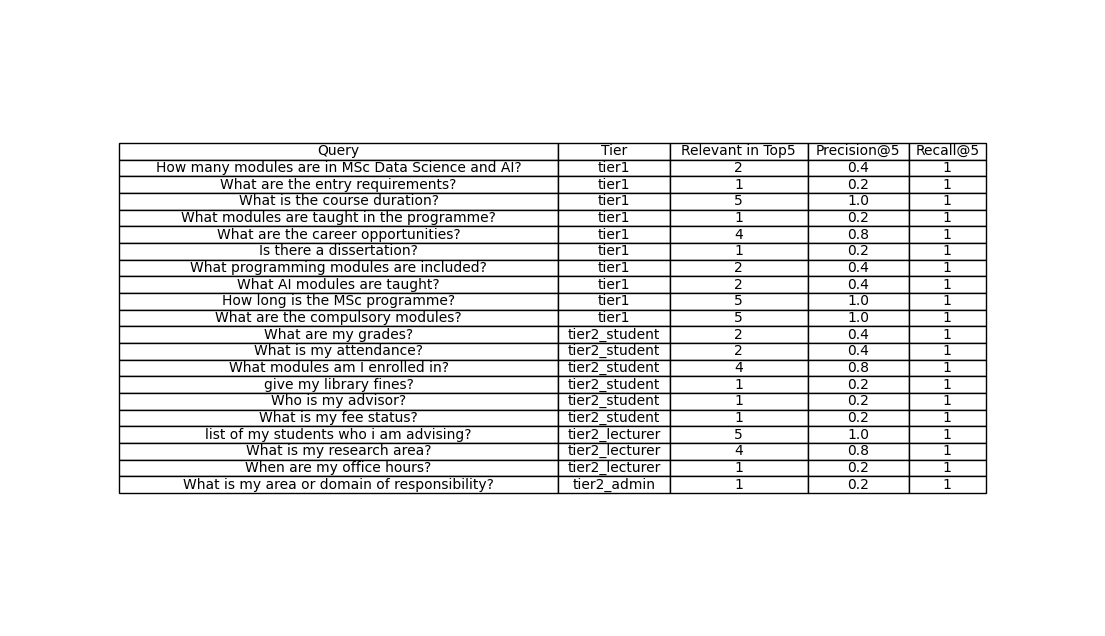

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results list to dataframe
df = pd.DataFrame(results)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

# Improve table formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df.columns))))

# Save image
image_path = r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\images"
plt.savefig(r"C:\Users\Harashaa Harshini\OneDrive\Desktop\Dessertation\images\rag_evaluation_results.png", bbox_inches='tight', dpi=300)

print("Table saved as rag_evaluation_results.png")

<center> <span style="color:navy;"> <h2> Security Evaluation: Role-Based Access Control Validation </h2> </span> </center>

This cell performs a security validation of the chatbot’s **Role-Based Access Control (RBAC)** mechanism within the Tier-2 personalised knowledge layer. The objective is to ensure that sensitive institutional information is accessed only by users with the appropriate permissions.

<h3 style="color:brown;"> 🔐 Role-Based Access Testing </h3>
A set of controlled test cases is defined, where different user roles (student, lecturer, and administrative staff) attempt to execute queries involving potentially sensitive information. Each test logs in a user with specific credentials and submits a query through the standard **route_and_answer()** pipeline.

<h3 style="color:brown;"> 👥 Multi-Role Query Simulation </h3>
The evaluation simulates realistic institutional scenarios. Students query their personal academic records, lecturers request information related to their advising responsibilities, and administrative staff attempt queries outside their operational domain. This helps verify that access policies are enforced correctly across different user roles.

<h3 style="color:brown;"> 🛡 Access Control Verification </h3>
For each test case, the system response is inspected to confirm whether the returned information aligns with the predefined access permissions. This ensures that the chatbot retrieves only authorised documents from the private knowledge base while preventing unintended exposure of restricted data.

<h3 style="color:brown;"> 🎯 Security Objective </h3>
The goal of this evaluation is to demonstrate that the two-tier architecture successfully integrates **secure personalised retrieval** with RBAC enforcement, ensuring that sensitive university data is handled responsibly and only accessible to authorised users.

In [284]:
security_tests = [

("s043","harshaa","What are my grades?","Student access"),
("l002","harshaa","What are my grades?","Lecturer restricted"),
("a003","harshaa","Who is my advisor?","Admin restricted"),
("l002","harshaa","Which students am I advising?","Lecturer allowed")

]

for user, pw, query, test in security_tests:

    login(user, pw, user_profiles)

    answer, retrieved = route_and_answer(query, CURRENT_USER)

    print("\nTest:", test)
    print("User:", user)
    print("Query:", query)
    print("Answer:", answer)

[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine

Test: Student access
User: s043
Query: What are my grades?
Answer: Your grades for the completed modules are as follows:

- Engineering Thermodynamics and Fluid Mechanics: A
- Engineering Design Challenge: C
- Structural Design and Materials: A
- Mathematics and Fluid Mechanics for Engineers: D
- Stress Analysis and FEA for Civil Engineers: A
[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine

Test: Lecturer restricted
User: l002
Query: What are my grades?
Answer: Your grades for the completed modules are as follows: 

- Engineering Thermodynamics and Fluid Mechanics: A
- Engineering Design Challenge: C
- Structural Design and Materials: A
- Mathematics and Fluid Mechanics for Engineers: D
- Stress Analysis and FEA for Civil Engineers: A
[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine

Test: Admin restricted
User: a003
Query: Who is my advisor?
Answer: Unfortunately, I 

In [288]:
import time
login("a004", "harshaa", user_profiles)

query = "what is my mail id ?"
start = time.time()

answer, retrieved = route_and_answer(query, CURRENT_USER)

end = time.time()

latency = round(end - start, 3)
print("Response time:", latency, "seconds")

[LOG] Intent detected: personal
[LOG] Routing to Tier-2 Personal Engine
Response time: 2.615 seconds
